<a href="https://colab.research.google.com/github/EnderA44hub/sales-analysis/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle

In [5]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

productos = ['Electronics', 'Food & Beverages', 'Sports', 'Home & Lifestyle', 'Fashion', 'Health & Beauty']
ciudades = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
metodos_pago = ['Cash', 'Credit card', 'E-wallet']

n = 1000
fechas = [datetime(2024, 1, 1) + timedelta(days=random.randint(0, 364)) for _ in range(n)]

df = pd.DataFrame({
    'Date': fechas,
    'City': random.choices(ciudades, k=n),
    'Product_line': random.choices(productos, k=n),
    'Unit_price': np.round(np.random.uniform(10, 100, n), 2),
    'Quantity': np.random.randint(1, 10, n),
    'Payment': random.choices(metodos_pago, k=n),
    'Customer_rating': np.round(np.random.uniform(4, 10, n), 1)
})

df['Total'] = np.round(df['Unit_price'] * df['Quantity'], 2)
df['Month'] = df['Date'].dt.month_name()
df['Day_of_week'] = df['Date'].dt.day_name()

df.head()

,Date,City,Product_line,Unit_price,Quantity,Payment,Customer_rating,Total,Month,Day_of_week
0,2024-11-23,Chicago,Sports,43.71,8,Cash,4.6,349.68,November,Saturday
1,2024-02-27,Houston,Home & Lifestyle,95.56,3,Cash,6.4,286.68,February,Tuesday
2,2024-01-13,Phoenix,Home & Lifestyle,75.88,8,Credit card,8.8,607.04,January,Saturday
3,2024-05-20,Phoenix,Food & Beverages,63.88,5,E-wallet,5.2,319.40,May,Monday
4,2024-05-05,New York,Home & Lifestyle,24.04,1,Cash,7.3,24.04,May,Sunday


In [7]:
print("Filas y columnas:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos:")
print(df.isnull().sum())

Filas y columnas: (1000, 10)

Tipos de datos:
Date               datetime64[ns]
City                       object
Product_line               object
Unit_price                float64
Quantity                    int64
Payment                    object
Customer_rating           float64
Total                     float64
Month                      object
Day_of_week                object
dtype: object

Nulos:
Date               0
City               0
Product_line       0
Unit_price         0
Quantity           0
Payment            0
Customer_rating    0
Total              0
Month              0
Day_of_week        0
dtype: int64


In [9]:
ventas_por_producto = df.groupby('Product_line')['Total'].sum().round(2).sort_values(ascending=False)
print("Ventas totales por línea de producto:")
print(ventas_por_producto)

Ventas totales por línea de producto:
Product_line
Fashion             52529.39
Food & Beverages    44132.85
Electronics         43789.00
Sports              43287.15
Home & Lifestyle    42751.62
Health & Beauty     40819.82
Name: Total, dtype: float64


In [11]:
ventas_por_ciudad = df.groupby('City')['Total'].sum().round(2).sort_values(ascending=False)
print("Ventas totales por ciudad:")
print(ventas_por_ciudad)

Ventas totales por ciudad:
City
Phoenix        60215.78
Houston        54610.07
Chicago        53693.76
Los Angeles    51727.09
New York       47063.13
Name: Total, dtype: float64


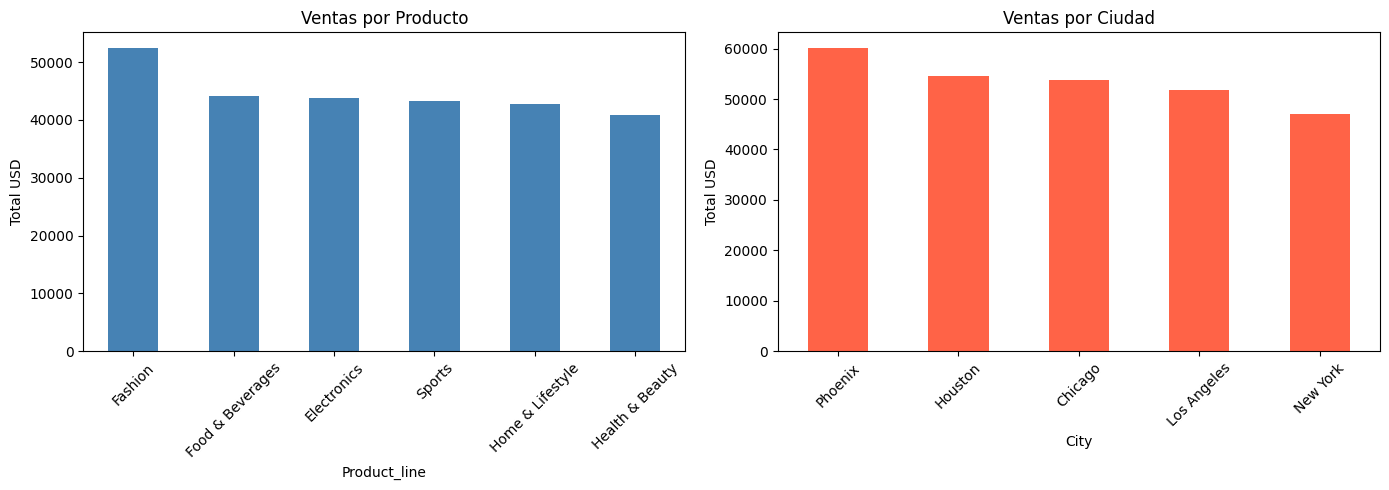

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ventas_por_producto.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Ventas por Producto')
ax1.set_ylabel('Total USD')
ax1.tick_params(axis='x', rotation=45)

ventas_por_ciudad.plot(kind='bar', ax=ax2, color='tomato')
ax2.set_title('Ventas por Ciudad')
ax2.set_ylabel('Total USD')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
import sqlite3

conn = sqlite3.connect(':memory:')

# Tabla 1: ventas
df.to_sql('ventas', conn, index=False, if_exists='replace')

# Tabla 2: metas por ciudad
metas = pd.DataFrame({
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'Meta_anual': [55000, 55000, 55000, 55000, 55000]
})
metas.to_sql('metas', conn, index=False, if_exists='replace')

print("Tablas creadas!")
print("\nTabla metas:")
print(metas)

Tablas creadas!

Tabla metas:
          City  Meta_anual
0     New York       55000
1  Los Angeles       55000
2      Chicago       55000
3      Houston       55000
4      Phoenix       55000


In [17]:
query = """
SELECT
    v.City,
    ROUND(SUM(v.Total), 2) as ventas_reales,
    m.Meta_anual,
    ROUND(SUM(v.Total) - m.Meta_anual, 2) as diferencia,
    ROUND(SUM(v.Total) * 100.0 / m.Meta_anual, 1) as pct_cumplimiento
FROM ventas v
JOIN metas m ON v.City = m.City
GROUP BY v.City
ORDER BY pct_cumplimiento DESC
"""

resultado = pd.read_sql(query, conn)
print(resultado)

          City  ventas_reales  Meta_anual  diferencia  pct_cumplimiento
0      Phoenix       60215.78       55000     5215.78             109.5
1      Houston       54610.07       55000     -389.93              99.3
2      Chicago       53693.76       55000    -1306.24              97.6
3  Los Angeles       51727.09       55000    -3272.91              94.0
4     New York       47063.13       55000    -7936.87              85.6


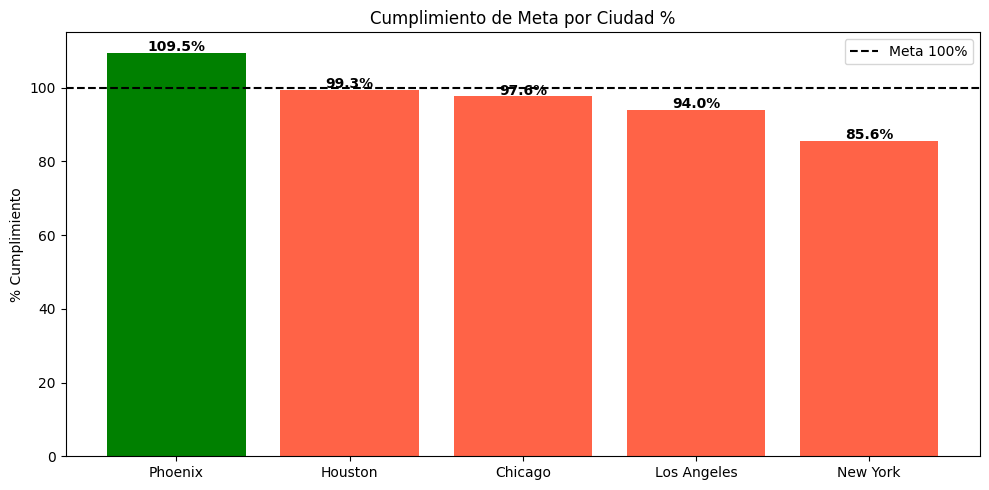

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['green' if x >= 100 else 'tomato' for x in resultado['pct_cumplimiento']]
bars = ax.bar(resultado['City'], resultado['pct_cumplimiento'], color=colores)
ax.axhline(y=100, color='black', linewidth=1.5, linestyle='--', label='Meta 100%')
ax.set_title('Cumplimiento de Meta por Ciudad %')
ax.set_ylabel('% Cumplimiento')
ax.legend()

for bar, val in zip(bars, resultado['pct_cumplimiento']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()